<a href="https://colab.research.google.com/github/gapalfaro-cmyk/gapalfaro-cmyk-Proyecto-de-fin-de-modulo-7.3---Alfaro-Badillo-Cruz-Perez-Rupit-/blob/main/Tarea3_Alfaro_Badillo_Cruz_Perez_Rupit_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 3

Vamos a usar una base de datos de rentas de bicicletas por hora `Bike Sharing Demand` disponible en Scikit-learn. Tenemos datos de la forma

$$(x_t, y_t),$$

donde $x_t$ es un vector de características, $y_t$ el número de biciletas rentadas al tiempo $t$. Aplicar el algoritmo *Online Gradient Descent* a esta base de datos y evaluar su Regret.

1. Descripción del problema
2. Metodología
3. Resultados, tablas, gráficas
4. Conclusiones

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit

bike = fetch_openml(
    name="Bike_Sharing_Demand",
    version=2,
    as_frame=True
)

In [ ]:
X = bike.data
y = bike.target

df = bike.frame
display(df.head(40))
display(df.info())
display(df["count"].value_counts())

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000,1
5,spring,0,1,5,False,6,False,misty,9.84,12.880,0.75,6.0032,1
6,spring,0,1,6,False,6,False,clear,9.02,13.635,0.80,0.0000,2
7,spring,0,1,7,False,6,False,clear,8.20,12.880,0.86,0.0000,3
8,spring,0,1,8,False,6,False,clear,9.84,14.395,0.75,0.0000,8
9,spring,0,1,9,False,6,False,clear,13.12,17.425,0.76,0.0000,14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   year        17379 non-null  int64   
 2   month       17379 non-null  int64   
 3   hour        17379 non-null  int64   
 4   holiday     17379 non-null  category
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  category
 7   weather     17379 non-null  category
 8   temp        17379 non-null  float64 
 9   feel_temp   17379 non-null  float64 
 10  humidity    17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  count       17379 non-null  int64   
dtypes: category(4), float64(4), int64(5)
memory usage: 1.3 MB


None

,count
count,
5,260
6,236
4,231
3,224
2,208
...,...
938,1
826,1
963,1


Entrenando OGD en línea...
Pérdida Media Final OGD: 0.5985
Pérdida Media Final Oráculo: 0.6013


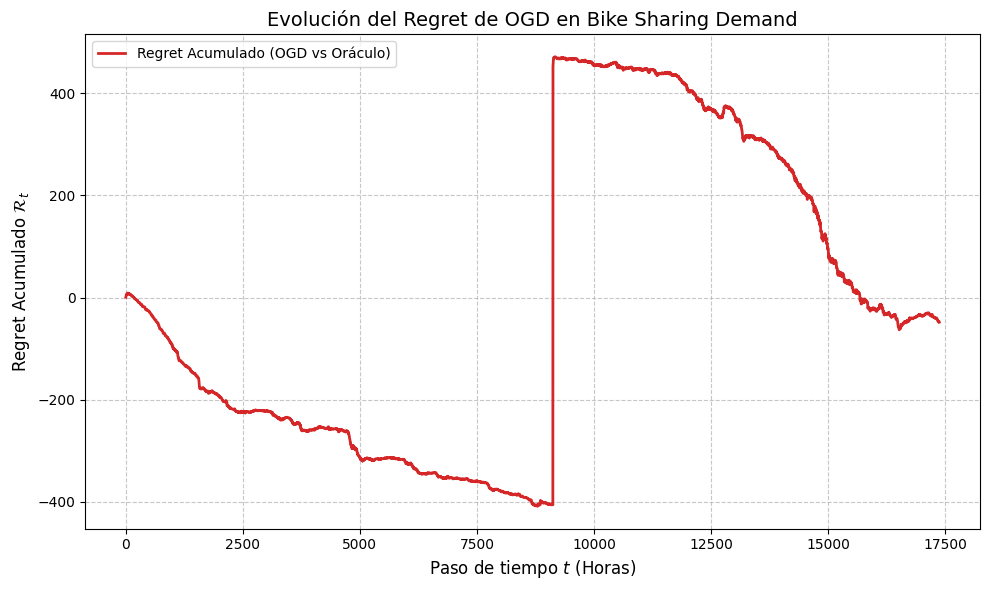

In [ ]:
# Seleccionamos variables predictoras y la variable objetivo (count)

# Identificamos columnas categóricas
categorical_features = ['season', 'holiday', 'workingday', 'weather']

# Creamos una copia del dataframe para aplicar one-hot encoding sin modificar el original
df_processed = df.copy()

# Aplicamos one-hot encoding a las variables categóricas
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=False)

# Seleccionamos todas las columnas de df_processed excepto 'count' para X_raw
# Esto incluye las columnas numéricas originales y las nuevas one-hot encoded.
predictor_columns = [col for col in df_processed.columns if col != 'count']

X_raw = df_processed[predictor_columns].astype(float).values
y_raw = df['count'].astype(float).values

# Estandarizamos X e y para evitar la explosión del gradiente
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

T, d = X.shape

# 2. Parámetros de OGD
w = np.zeros(d)
eta = 0.001  # Tasa de aprendizaje pequeña por la naturaleza del MSE online

online_losses = []
cumulative_online_loss = 0.0

# 3. Calcular el mejor predictor fijo en retrospectiva (Oráculo OLS)
# Utilizamos la seudoinversa para encontrar los pesos óptimos globales w*
w_star = np.linalg.lstsq(X, y, rcond=None)[0]

# Precalculamos las pérdidas del oráculo para cada instante t
fixed_losses = (X @ w_star - y) ** 2
cumulative_fixed_loss = 0.0

regret_curve = []

print("Entrenando OGD en línea...")
# 4. Bucle principal de Online Gradient Descent
for t in range(T):
    x_t = X[t]
    y_t = y[t]
    # Predecir y calcular pérdida instantánea
    pred_t = np.dot(w, x_t)
    loss_t = (pred_t - y_t) ** 2
    online_losses.append(loss_t)
    cumulative_online_loss += loss_t
    cumulative_fixed_loss += fixed_losses[t]
    # Calcular Regret hasta el tiempo t
    regret_t = cumulative_online_loss - cumulative_fixed_loss
    regret_curve.append(regret_t)
    # Actualización estocástica usando el gradiente
    grad = 2 * (pred_t - y_t) * x_t
    w = w - eta * grad

print(f"Pérdida Media Final OGD: {cumulative_online_loss/T:.4f}")
print(f"Pérdida Media Final Oráculo: {np.sum(fixed_losses)/T:.4f}")

# 5. Visualización del Regret
plt.figure(figsize=(10, 6))
plt.plot(regret_curve, color='#d62728', linewidth=2, label="Regret Acumulado (OGD vs Oráculo)")
plt.xlabel("Paso de tiempo $t$ (Horas)", fontsize=12)
plt.ylabel(r"Regret Acumulado $\mathcal{R}_t$", fontsize=12)
plt.title("Evolución del Regret de OGD en Bike Sharing Demand", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
y = df["count"]

X = df.drop(columns="count")

X.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

X_encoded.head()

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,season_fall,season_spring,season_summer,season_winter,holiday_False,holiday_True,workingday_False,workingday_True,weather_clear,weather_heavy_rain,weather_misty,weather_rain
0,0,1,0,6,9.84,14.395,0.81,0.0,False,True,False,False,True,False,True,False,True,False,False,False
1,0,1,1,6,9.02,13.635,0.80,0.0,False,True,False,False,True,False,True,False,True,False,False,False
2,0,1,2,6,9.02,13.635,0.80,0.0,False,True,False,False,True,False,True,False,True,False,False,False
3,0,1,3,6,9.84,14.395,0.75,0.0,False,True,False,False,True,False,True,False,True,False,False,False
4,0,1,4,6,9.84,14.395,0.75,0.0,False,True,False,False,True,False,True,False,True,False,False,False


In [ ]:
X_encoded.shape

(17379, 20)

Descargando dataset 'Bike Sharing Demand'...
Entrenando OGD en línea y calculando Oráculo iterativo...


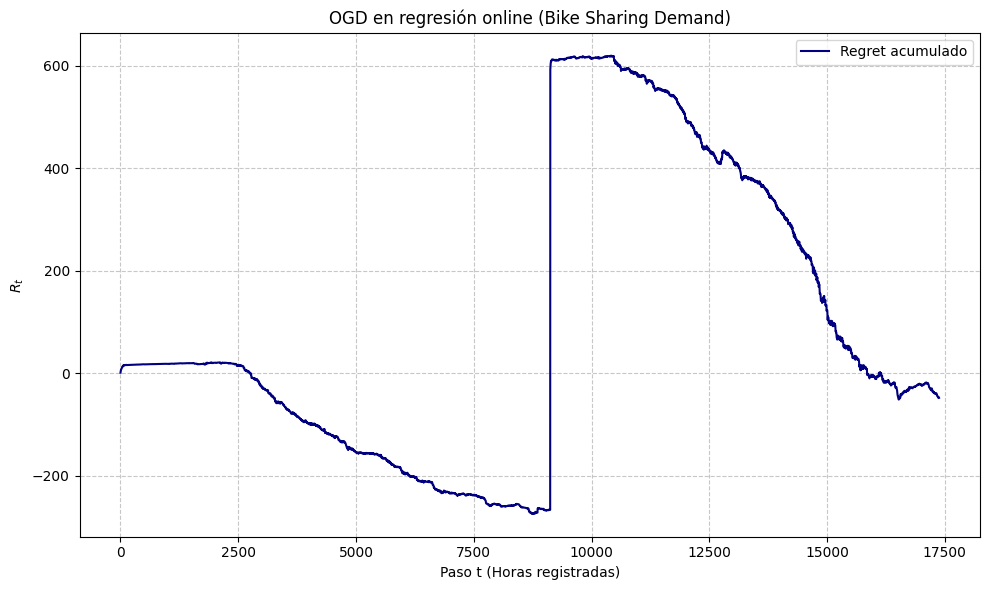

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

# --- PREPARACIÓN DE DATOS REALES ---
print("Descargando dataset 'Bike Sharing Demand'...")
bike_data = fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True, parser="auto")
df = bike_data.frame

# Identificamos columnas categóricas
categorical_features = ['season', 'holiday', 'workingday', 'weather']

# Creamos una copia del dataframe para aplicar one-hot encoding
df_processed = df.copy()

# Aplicamos one-hot encoding a las variables categóricas
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=False)

# Seleccionamos las columnas predictoras del dataframe procesado
# Excluimos la columna objetivo 'count'
predictor_columns = [col for col in df_processed.columns if col != 'count']
X_raw = df_processed[predictor_columns].astype(float).values
y_raw = df['count'].astype(float).values

# Estandarización obligatoria para evitar explosión de gradiente con MSE
X = StandardScaler().fit_transform(X_raw)
y = StandardScaler().fit_transform(y_raw.reshape(-1, 1)).flatten()

n = X.shape[0]

# --- ESTRUCTURA EXACTA DEL PROFESOR (OGD) ---
w = np.zeros(X.shape[1])
eta = 0.001  # Ajustado a 0.001 para la magnitud de este dataset

cumulative_online_loss = 0.0
online_losses = []
regret_curve = []

print("Entrenando OGD en línea y calculando Oráculo iterativo...")

for t in range(n):
    x_t = X[t]
    y_t = y[t]

    # 1. Predecir antes de actualizar
    pred_t = np.dot(w, x_t)

    # 2. Sufrir la pérdida
    loss_t = (pred_t - y_t) ** 2
    online_losses.append(loss_t)
    cumulative_online_loss += loss_t

    # 3. Mejor predictor fijo para las observaciones 1,...,t
    X_prefix = X[:t + 1]
    y_prefix = y[:t + 1]

    w_star_t = np.linalg.lstsq(
        X_prefix,
        y_prefix,
        rcond=None
    )[0]

    best_fixed_loss = np.sum(
        (X_prefix @ w_star_t - y_prefix) ** 2
    )

    # 4. Regret hasta el tiempo t
    regret_t = cumulative_online_loss - best_fixed_loss
    regret_curve.append(regret_t)

    # 5. Actualizar después de observar la pérdida
    grad = 2 * (pred_t - y_t) * x_t
    w = w - eta * grad

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(regret_curve, color='navy', label="Regret acumulado")
plt.xlabel("Paso t (Horas registradas)")
plt.ylabel(r"$R_t$")
plt.title("OGD en regresión online (Bike Sharing Demand)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()